#### 시너지별 승률 기준으로 이상치 찾기
- Isolation Forest

In [1]:
# 데이터 호출
import pandas as pd

df_combination = pd.read_csv('../../유저단위_게임데이터_상위랭커보존-stats_combination_1.csv')


In [2]:
print(df_combination.info())

display(df_combination.head(1))

<class 'pandas.DataFrame'>
RangeIndex: 396239 entries, 0 to 396238
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   gameid               396239 non-null  str  
 1   user_tier            396239 non-null  str  
 2   ranked               396239 non-null  int64
 3   user_id              396239 non-null  str  
 4   flag_1               396239 non-null  int64
 5   flag_2               396239 non-null  int64
 6   active_synergies     396239 non-null  str  
 7   top4_flag            396239 non-null  bool 
 8   ranked_1             396239 non-null  bool 
 9   combination_rebuild  396239 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB
None


,gameid,user_tier,ranked,user_id,flag_1,flag_2,active_synergies,top4_flag,ranked_1,combination_rebuild
0,KR_4291707834,platinum,5,KR-USER-1,0,0,{},False,False,"{'Cybernetic': 1, 'Demolitionist': 1, 'Infiltr..."


In [3]:
# gameid별 유저 수 확인
game_user_count = df_combination.groupby('gameid')['user_id'].nunique()

# 8명이 참여한 게임만 추출
valid_games = game_user_count[game_user_count == 8].index

# 필터링
df_combo_valid = df_combination[df_combination['gameid'].isin(valid_games)]

print(f'전체 게임 수: {df_combination["gameid"].nunique()}')
print(f'8명 풀게임 수: {df_combo_valid["gameid"].nunique()}')
print(f'필터링 후 행 수: {len(df_combo_valid)}')

전체 게임 수: 49563
8명 풀게임 수: 49344
필터링 후 행 수: 394752


In [4]:
import ast

# active_synergies 파싱
df_combo_valid['active_synergies'] = df_combo_valid['active_synergies'].apply(ast.literal_eval)

# 조합 리스트 추출
df_combo_valid['combo_list_active'] = df_combo_valid['active_synergies'].apply(
    lambda x: list(x.keys()) if x else []
)

# 시너지 단위로 explode
df_combo_exploded = df_combo_valid.explode('combo_list_active')

# 빈 값 제거
df_combo_exploded = df_combo_exploded[df_combo_exploded['combo_list_active'] != '']

print(df_combo_exploded.shape)

(1768022, 11)


In [5]:
# 시너지별 통계 집계 (8명 풀게임 기준)
total_user_games_valid = len(df_combo_valid[['gameid', 'user_id']].drop_duplicates())

combo_stats_valid = df_combo_exploded.groupby('combo_list_active').agg(
    pick_count=('combo_list_active', 'count'),
    avg_rank=('ranked', 'mean'),
    win_rate=('ranked_1', 'mean'),
    top4_rate=('top4_flag', 'mean')
).reset_index()

# 픽률 계산
combo_stats_valid['pick_rate'] = combo_stats_valid['pick_count'] / total_user_games_valid

display(combo_stats_valid.head(5))

,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate
0,Blademaster,103601,4.425179,0.127856,0.513489,0.262446
1,Blaster,115117,4.263011,0.129138,0.544880,0.291619
2,Brawler,100734,4.335200,0.122104,0.532601,0.255183
3,Celestial,136709,4.288108,0.142353,0.538063,0.346316
4,Chrono,199768,4.245855,0.138270,0.548471,0.506060


In [6]:
combo_stats_valid.to_csv('./combination_stats_by_full_game(ML).csv', index=False, encoding='utf-8-sig')

---

#### Isolation_Forest를 사용해서 이상치 탐색하기

##### Isolation_Forest에서 피처의 의미

- 피처로 선택한 변수들을 기준으로 "다른 데이터와 얼마나 다른가"를 측정
- 피처가 많을수록 → 여러 변수를 종합해서 이상치 판단
- 피처가 적을수록 → 특정 변수에 집중해서 이상치 판단

In [7]:
# 라이브러리 호출
from sklearn.ensemble import IsolationForest


random_seed = 42

In [8]:
# 피처 선택
X = combo_stats_valid[['win_rate', 'pick_rate']]

In [9]:
# Isolation_Forest 모델 정의

iso_forest_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# anomaly: Isolation Forest가 각 데이터를 분류한 결과
    # 1 → 정상 (다른 시너지들과 비슷한 패턴)
    # -1 → 이상치 (다른 시너지들과 패턴이 다름)
    
# anomaly_score: 각 데이터가 얼마나 이상치에 가까운지를 나타내는 점수
    # 0에 가까울수록 → 정상
    # 음수일수록 → 이상치에 가까움

In [10]:
# 이상치 탐지
combo_stats_valid['anomaly'] = iso_forest_model.fit_predict(X)
combo_stats_valid['anomaly_score'] = iso_forest_model.score_samples(X)

# 결과 확인
print(f'이상치 개수: {(combo_stats_valid["anomaly"] == -1).sum()}')
print(f'정상 개수: {(combo_stats_valid["anomaly"] == 1).sum()}')
display(combo_stats_valid.sort_values('anomaly_score'))

이상치 개수: 2
정상 개수: 21


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
19,Starship,23045,3.540291,0.199479,0.688349,0.058378,-1,-0.663499
4,Chrono,199768,4.245855,0.138270,0.548471,0.506060,-1,-0.651273
12,Mystic,66761,3.999596,0.186246,0.589656,0.169121,1,-0.563251
11,Mercenary,126652,3.942764,0.158742,0.605431,0.320839,1,-0.515432
22,Void,19249,4.248532,0.143280,0.543509,0.048762,1,-0.513082
2,Brawler,100734,4.335200,0.122104,0.532601,0.255183,1,-0.510324
5,Cybernetic,41515,4.466289,0.123714,0.506516,0.105167,1,-0.504016
3,Celestial,136709,4.288108,0.142353,0.538063,0.346316,1,-0.497605
1,Blaster,115117,4.263011,0.129138,0.544880,0.291619,1,-0.488223
7,Demolitionist,45798,4.092449,0.170575,0.570855,0.116017,1,-0.478789


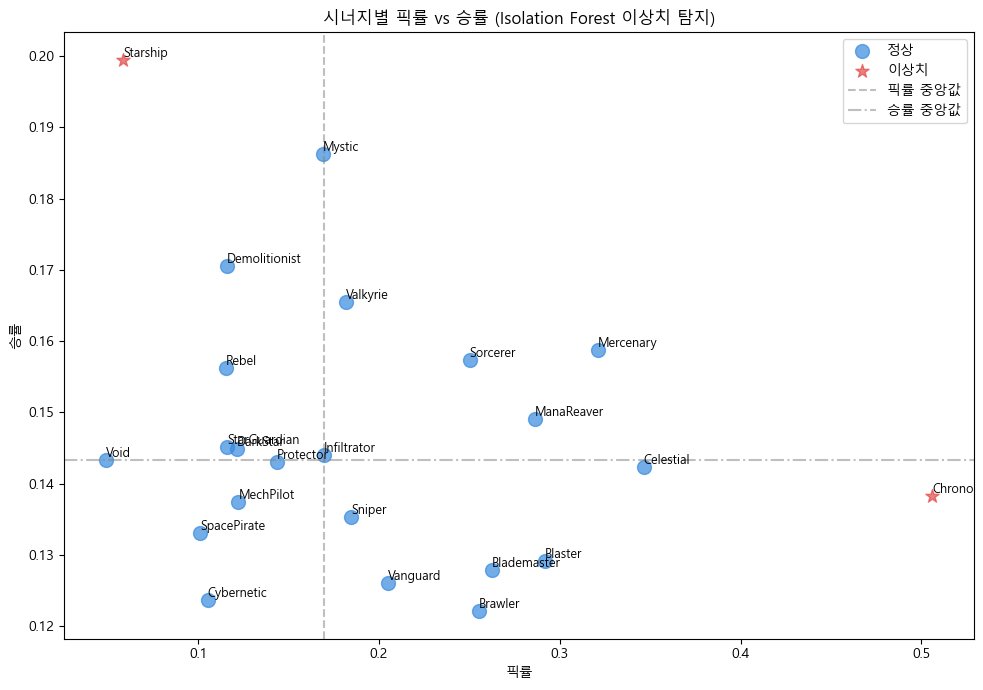

In [11]:
import matplotlib.pyplot as plt
import platform
    
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))

# 정상 / 이상치 분리
normal = combo_stats_valid[combo_stats_valid['anomaly'] == 1]
anomaly = combo_stats_valid[combo_stats_valid['anomaly'] == -1]

# 정상 산점도
ax.scatter(normal['pick_rate'], normal['win_rate'], 
        c='#378ADD', label='정상', alpha=0.7, s=100)

# 이상치 산점도
ax.scatter(anomaly['pick_rate'], anomaly['win_rate'], 
        c='#E24B4A', label='이상치', alpha=0.7, s=100, marker='*')

# 시너지 이름 표시
for _, row in combo_stats_valid.iterrows():
        ax.annotate(row['combo_list_active'], 
                        (row['pick_rate'], row['win_rate']),
                        fontsize=9, ha='left', va='bottom')

# 기준선 (중앙값)
ax.axvline(combo_stats_valid['pick_rate'].median(), 
        color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
ax.axhline(combo_stats_valid['win_rate'].median(), 
        color='gray', linestyle='-.', alpha=0.5, label='승률 중앙값')

ax.set_xlabel('픽률')
ax.set_ylabel('승률')
ax.set_title('시너지별 픽률 vs 승률 (Isolation Forest 이상치 탐지)')
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
print(f'contamination: {iso_forest_model.contamination}')
print(f'전체 시너지 수: {len(combo_stats_valid)}')
print(f'이상치 개수: {(combo_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(combo_stats_valid["anomaly"] == -1).sum() / len(combo_stats_valid):.2%}')

contamination: 0.05
전체 시너지 수: 23
이상치 개수: 2
이상치 비율: 8.70%
